# DeGroot model: how influence can shape opinions

People influence one another through social relationships. A network lets us ask theoretical questions such as:

- Can repeated interpersonal influence produce consensus?
- How does network structure affect the speed of convergence?
- Which assumptions are responsible for the observed outcome?

The value of the model is not that it reproduces society exactly. Its value is that it makes assumptions explicit and lets us examine their consequences.

## The DeGroot model

Each agent $i$ has a continuous opinion

$$
x_i(t) \in [0,1].
$$

At every round, all agents update synchronously:

$$
x_i(t+1)=\sum_{j=1}^{N} W_{ij}x_j(t),
$$
where $W_{ij}$ is the influence that agent $j$ has on agent $i$. The weights are nonnegative and every row sums to one:

$$
\sum_j W_{ij}=1.
$$

In this example, an agent gives equal weight to its own opinion and to the opinions of its network neighbors.

### Conventions used here

- **Opinion space:** continuous values in $[0,1]$.
- **Population:** 100 agents.
- **Network structure:** two fixed, simple, connected, undirected Watts-Strogatz (WS) networks, with 2 and 7 lattice neighbors on each side.
- **Initial state:** each opinion is sampled independently from the uniform distribution on $[0,1]$ using `OPINION_SEED`.
- **Influence:** equal weight for the agent and each of its neighbors.
- **Update schedule:** synchronous; every update uses the unchanged opinions from the previous round.
- **Time:** one step means one complete update of all agents.
- **Observable:** the range between the largest and smallest opinions measures disagreement.
- **Consensus criterion:** opinion range strictly smaller than `CONSENSUS_TOLERANCE`.
- **Simulation horizon:** exactly `N_ROUNDS`; detecting consensus does not stop the simulation early.
- **Parameter ranges:** `N_ROUNDS >= 0`, `0 <= REWIRING_PROBABILITY <= 1`, each `NEIGHBORS_ON_EACH_SIDE` value is in $[1, N_AGENTS / 2)$, and `CONSENSUS_TOLERANCE > 0`.

A row-stochastic influence matrix does not guarantee consensus for every network. For a fixed DeGroot model, strong connectivity ensures that influence can propagate between all agents, while positive self-weights remove periodicity, such as alternating oscillations. Together, strong connectivity and positive self-weights make the influence matrix primitive, which guarantees asymptotic consensus.

The limiting consensus opinion is not generally the arithmetic mean of the initial opinions because a row-stochastic influence matrix need not be column-stochastic.

In [1]:
import random
import igraph as ig
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np

# Adjustable parameters
N_AGENTS = 100
N_ROUNDS = 50
NEIGHBORS_ON_EACH_SIDE = (2, 7)
REWIRING_PROBABILITY = 0.10
CONSENSUS_TOLERANCE = 0.01

# Visible fixed seeds make the example reproducible within this environment.
NETWORK_SEED = 2026
OPINION_SEED = 2027
LAYOUT_SEED = 2028
MAX_NETWORK_ATTEMPTS = 20

assert N_ROUNDS >= 0
assert 0 <= REWIRING_PROBABILITY <= 1
assert all(1 <= neighbor_count < N_AGENTS / 2 for neighbor_count in NEIGHBORS_ON_EACH_SIDE)
assert CONSENSUS_TOLERANCE > 0
assert MAX_NETWORK_ATTEMPTS > 0

plt.rcParams.update({
    "figure.figsize": (8, 4),
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

## 1. Create two social networks

We use `igraph` to create, store, lay out, and draw two WS networks. The values in `NEIGHBORS_ON_EACH_SIDE` start each agent with either two or seven neighbors on each side.

This synthetic structure is a convenient theoretical influence structure, not a reconstruction of a real social network.

Both cases reuse the same initial opinions.

In [2]:
def generate_connected_network(neighbor_count):
    """Return a reproducible simple, connected network for one neighborhood size."""
    for attempt in range(MAX_NETWORK_ATTEMPTS):
        graph_seed = NETWORK_SEED + 1_000 * neighbor_count + attempt
        ig.set_random_number_generator(random.Random(graph_seed))
        graph = ig.Graph.Watts_Strogatz(
            dim=1,
            size=N_AGENTS,
            nei=neighbor_count,
            p=REWIRING_PROBABILITY,
        )
        if graph.is_simple() and graph.is_connected():
            return graph, graph_seed

    raise RuntimeError(
        f"No connected network found for {neighbor_count} neighbors "
        f"after {MAX_NETWORK_ATTEMPTS} deterministic attempts."
    )


graphs = {}
layouts = {}
network_seeds = {}

for neighbor_count in NEIGHBORS_ON_EACH_SIDE:
    graph, graph_seed = generate_connected_network(neighbor_count)
    assert graph.vcount() == N_AGENTS
    assert graph.vs.indices == list(range(N_AGENTS))

    layout_rng = np.random.default_rng(LAYOUT_SEED + neighbor_count)
    layout_start = layout_rng.uniform(-1.0, 1.0, size=(N_AGENTS, 2))
    layout = graph.layout_fruchterman_reingold(seed=layout_start.tolist(), niter=1000)
    assert len(layout) == N_AGENTS

    graphs[neighbor_count] = graph
    layouts[neighbor_count] = layout
    network_seeds[neighbor_count] = graph_seed

opinion_rng = np.random.default_rng(OPINION_SEED)
initial_opinions = opinion_rng.uniform(0.0, 1.0, size=N_AGENTS)

for neighbor_count in NEIGHBORS_ON_EACH_SIDE:
    graph = graphs[neighbor_count]
    print(
        f"{neighbor_count} neighbors on each side: "
        f"{graph.ecount()} connections; seed {network_seeds[neighbor_count]}"
    )

2 neighbors on each side: 200 connections; seed 4026
7 neighbors on each side: 700 connections; seed 9026


Average degree for 2 neighbors on each side: 4.00
Average degree for 7 neighbors on each side: 14.00


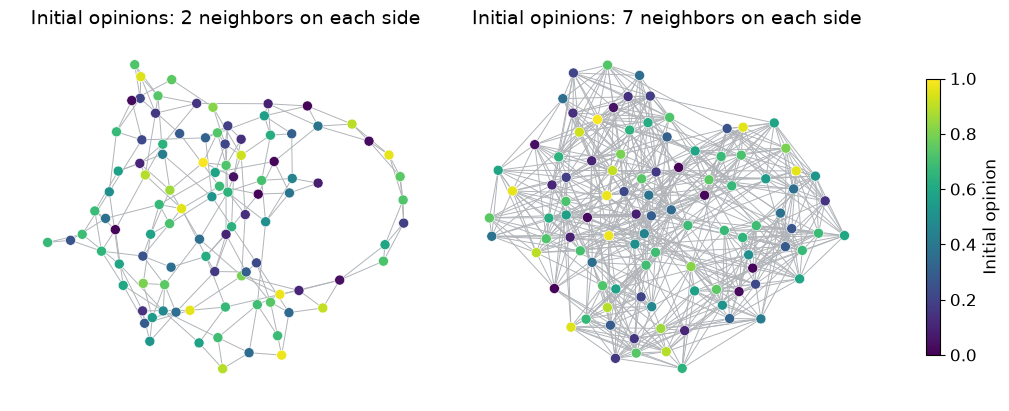

In [3]:
opinion_norm = mcolors.Normalize(vmin=0.0, vmax=1.0)
opinion_cmap = plt.colormaps["viridis"]
opinion_color_scale = plt.cm.ScalarMappable(
    norm=opinion_norm,
    cmap=opinion_cmap,
)


def draw_opinion_network(ax, graph, layout, opinions, title, vertex_size):
    """Draw opinions on an igraph network using vertex-ID order."""
    vertex_colors = [
        mcolors.to_hex(opinion_cmap(opinion_norm(value)))
        for value in opinions
    ]

    ig.plot(
        graph,
        target=ax,
        layout=layout,
        vertex_color=vertex_colors,
        vertex_size=vertex_size,
        vertex_frame_color="white",
        vertex_frame_width=0.4,
        vertex_label=None,
        edge_color="#b0b4b8",
        edge_width=0.7,
        autocurve=False,
    )
    ax.set_title(title)
    ax.axis("off")


fig, axes = plt.subplots(1, 2, figsize=(10, 4), layout="constrained")

for ax, neighbor_count in zip(axes, NEIGHBORS_ON_EACH_SIDE):
    draw_opinion_network(
        ax,
        graphs[neighbor_count],
        layouts[neighbor_count],
        initial_opinions,
        f"Initial opinions: {neighbor_count} neighbors on each side",
        vertex_size=10,
    )
    print(f"Average degree for {neighbor_count} neighbors on each side: {np.mean(graphs[neighbor_count].degree()):.2f}")

fig.colorbar(opinion_color_scale, ax=axes, label="Initial opinion", shrink=0.75)
plt.savefig("figures/initial_opinions.pdf")
plt.show()

## 2. Translate the theory into code

Each adjacency matrix tells us which agents are connected. We add the identity matrix because each agent also considers its own opinion.

Dividing each row by its sum gives equal influence to the agent and all of its neighbors. The resulting matrix $W$ is row-stochastic.

For this undirected equal-neighbor construction, the theoretical consensus value is

$$
x^* =
\frac{\sum_i (d_i+1)x_i(0)}
     {\sum_i (d_i+1)},
$$

where $d_i$ is the degree of agent $i$. Agents with more neighbors have greater weight in the limiting opinion. We calculate one influence matrix and one theoretical consensus value for each network.

In [4]:
influence_weights = {}
theoretical_consensus = {}

for neighbor_count in NEIGHBORS_ON_EACH_SIDE:
    graph = graphs[neighbor_count]
    adjacency = np.asarray(graph.get_adjacency().data, dtype=float)
    assert adjacency.shape == (N_AGENTS, N_AGENTS)
    assert np.array_equal(adjacency, adjacency.T)
    assert np.all(np.diag(adjacency) == 0)

    # A + I includes both neighbors and the agent itself.
    influence_connections = adjacency + np.eye(N_AGENTS)
    row_totals = influence_connections.sum(axis=1, keepdims=True)
    assert np.allclose(row_totals.ravel(), np.asarray(graph.degree()) + 1)

    # Normalize each row so that its influence weights sum to one.
    weights = influence_connections / row_totals
    assert np.all(weights >= 0)
    assert np.allclose(weights.sum(axis=1), 1.0)

    influence_weights[neighbor_count] = weights
    theoretical_consensus[neighbor_count] = np.average(
        initial_opinions,
        weights=row_totals.ravel(),
    )

    print(
        f"{neighbor_count} neighbors on each side - theoretical consensus: "
        f"{theoretical_consensus[neighbor_count]:.3f}"
    )

2 neighbors on each side - theoretical consensus: 0.506
7 neighbors on each side - theoretical consensus: 0.506


## 3. Run synchronous DeGroot updates

The function stores the initial opinions and every later round. Each new state is computed from the complete previous state, matching the synchronous update equation. We use the same initial state for both networks.

In [5]:
def simulate_degroot(weights, initial_state, n_rounds):
    """Return opinions from round 0 through round n_rounds."""
    history = np.empty((n_rounds + 1, len(initial_state)))
    history[0] = initial_state

    for round_index in range(n_rounds):
        previous_opinions = history[round_index].copy()
        history[round_index + 1] = weights @ previous_opinions

    return history


opinion_histories = {}
final_opinions = {}

for neighbor_count in NEIGHBORS_ON_EACH_SIDE:
    opinion_history = simulate_degroot(
        influence_weights[neighbor_count],
        initial_opinions,
        N_ROUNDS,
    )

    # Convex averaging keeps opinions inside their initial range.
    assert opinion_history.min() >= initial_opinions.min() - 1e-12
    assert opinion_history.max() <= initial_opinions.max() + 1e-12

    # The maximum-minus-minimum disagreement cannot increase.
    assert np.all(np.diff(np.ptp(opinion_history, axis=1)) <= 1e-12)

    opinion_histories[neighbor_count] = opinion_history
    final_opinions[neighbor_count] = opinion_history[-1]

## 4. Compare the initial and final states

Each column follows one network from its common initial opinions to its opinions after `N_ROUNDS` updates. Within and across panels, the color scale stays fixed, so differences reflect opinions rather than plotting choices.

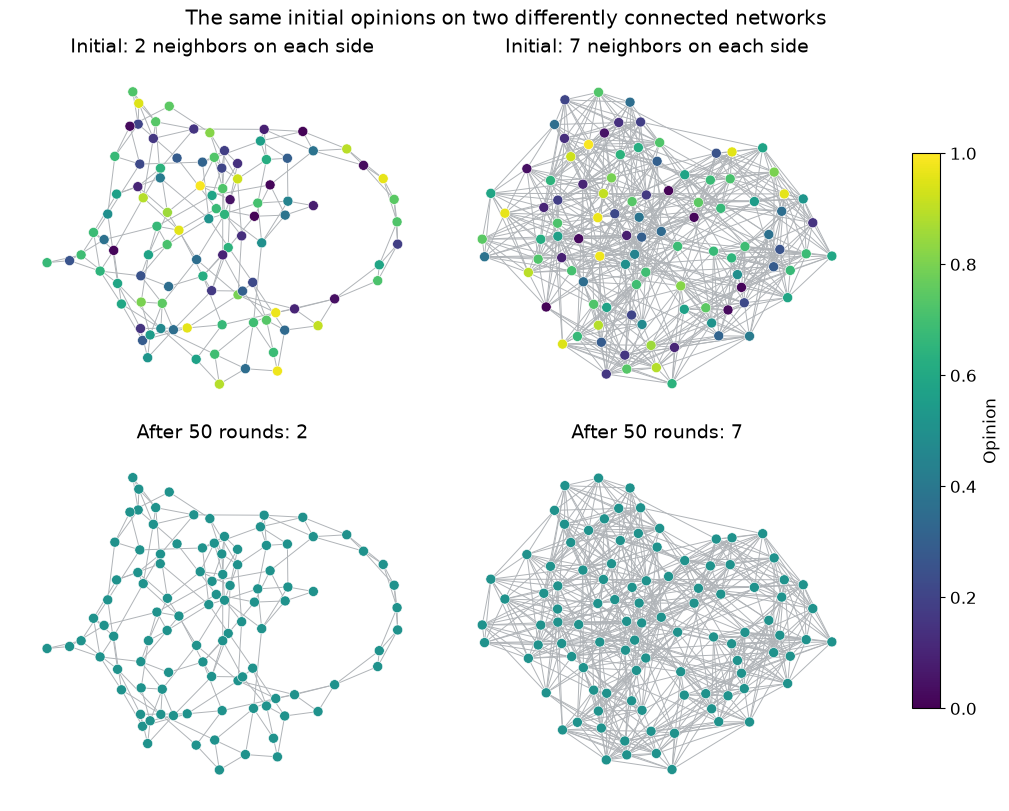

In [6]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(10, 8),
    layout="constrained",
)

for column, neighbor_count in enumerate(NEIGHBORS_ON_EACH_SIDE):
    graph = graphs[neighbor_count]
    layout = layouts[neighbor_count]
    draw_opinion_network(
        axes[0, column],
        graph,
        layout,
        initial_opinions,
        f"Initial: {neighbor_count} neighbors on each side",
        vertex_size=10,
    )
    draw_opinion_network(
        axes[1, column],
        graph,
        layout,
        final_opinions[neighbor_count],
        f"After {N_ROUNDS} rounds: {neighbor_count}",
        vertex_size=10,
    )

fig.colorbar(
    opinion_color_scale,
    ax=axes.ravel(),
    label="Opinion",
    shrink=0.75,
)
fig.suptitle("The same initial opinions on two differently connected networks")
plt.savefig("figures/initial_and_final_opinions.pdf")
plt.show()

## 5. Does network density change convergence time?

A common analysis follows opinion trajectories and summarizes their dispersion over time. The left panel shows all trajectories separately for each network; the right panel directly compares their disagreement ranges.

Here, disagreement is defined as

$$
\max_i x_i(t)-\min_i x_i(t).
$$

Consensus is operationally detected when this range becomes smaller than the chosen tolerance. Because both cases start from the same opinions and use the same update clock, their first detected consensus rounds can be compared.

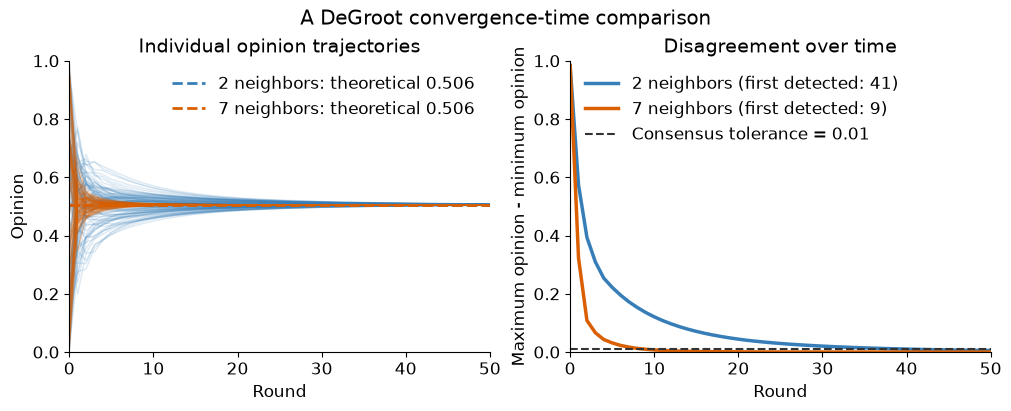

2 neighbors: first consensus detection at round 41.
  Largest final deviation from theory: 0.002699
7 neighbors: first consensus detection at round 9.
  Largest final deviation from theory: 0.000000


In [7]:
rounds = np.arange(N_ROUNDS + 1)
opinion_ranges = {}
first_consensus_rounds = {}
colors = {2: "#377eb8", 7: "#d95f02"}

for neighbor_count in NEIGHBORS_ON_EACH_SIDE:
    opinion_range = np.ptp(opinion_histories[neighbor_count], axis=1)
    consensus_rounds = np.flatnonzero(opinion_range < CONSENSUS_TOLERANCE)

    opinion_ranges[neighbor_count] = opinion_range
    first_consensus_rounds[neighbor_count] = (
        int(consensus_rounds[0]) if consensus_rounds.size else None
    )

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 4),
    layout="constrained",
)

for neighbor_count in NEIGHBORS_ON_EACH_SIDE:
    axes[0].plot(
        rounds,
        opinion_histories[neighbor_count],
        color=colors[neighbor_count],
        alpha=0.17,
        linewidth=1,
    )
    axes[0].axhline(
        theoretical_consensus[neighbor_count],
        color=colors[neighbor_count],
        linestyle="--",
        linewidth=2,
        label=(
            f"{neighbor_count} neighbors: theoretical "
            f"{theoretical_consensus[neighbor_count]:.3f}"
        ),
    )

axes[0].set(
    title="Individual opinion trajectories",
    xlabel="Round",
    ylabel="Opinion",
    ylim=(0, 1),
    xlim=(0, N_ROUNDS),
)
axes[0].spines[["top", "right"]].set_visible(False)
axes[0].legend(frameon=False)

for neighbor_count in NEIGHBORS_ON_EACH_SIDE:
    convergence_time = first_consensus_rounds[neighbor_count]
    time_label = (
        str(convergence_time)
        if convergence_time is not None
        else f"> {N_ROUNDS}"
    )
    axes[1].plot(
        rounds,
        opinion_ranges[neighbor_count],
        color=colors[neighbor_count],
        linewidth=2.5,
        label=(
            f"{neighbor_count} neighbors (first detected: {time_label})"
        ),
    )

axes[1].axhline(
    CONSENSUS_TOLERANCE,
    color="#333333",
    linestyle="--",
    label=f"Consensus tolerance = {CONSENSUS_TOLERANCE}",
)
axes[1].set(
    title="Disagreement over time",
    xlabel="Round",
    ylabel="Maximum opinion - minimum opinion",
    xlim=(0, N_ROUNDS),
    ylim=(0, 1),
)
axes[1].spines[["top", "right"]].set_visible(False)
axes[1].legend(frameon=False, loc="upper left")

plt.savefig("figures/consensus_time.pdf")

fig.suptitle("A DeGroot convergence-time comparison")
plt.show()

for neighbor_count in NEIGHBORS_ON_EACH_SIDE:
    convergence_time = first_consensus_rounds[neighbor_count]
    if convergence_time is None:
        print(
            f"{neighbor_count} neighbors: no consensus "
            f"detected within {N_ROUNDS} rounds."
        )
    else:
        print(
            f"{neighbor_count} neighbors: first consensus "
            f"detection at round {convergence_time}."
        )

    largest_deviation = np.max(
        np.abs(final_opinions[neighbor_count] - theoretical_consensus[neighbor_count])
    )
    print(f"  Largest final deviation from theory: {largest_deviation:.6f}")

## Interpretation and limitations

For both connected networks with positive self-weights, DeGroot theory guarantees asymptotic consensus. This paired simulation illustrates how the same initial opinions converge under two different local-connectivity choices. The first round below `CONSENSUS_TOLERANCE` is a finite-horizon, operational measure of convergence time, not the exact time to mathematical consensus.

This mathematical conclusion follows from the model assumptions. It is not evidence that a real population must reach consensus, nor that denser networks always converge faster for every topology and weighting rule.

The model deliberately omits many real mechanisms, including changing relationships, strategic communication, unequal trust beyond network degree, external information, multidimensional beliefs, emotion, institutions, and individual resistance to influence.

Therefore:

- the networks are theoretical representations of possible influence;
- the update equation is a proposed mechanism;
- the paired trajectories illustrate consequences of those assumptions;
- the result is not a prediction or complete description of reality.

### References

DeGroot, M. H. (1974). *Reaching a Consensus*. Journal of the American Statistical Association, 69(345), 118-121. [doi:10.1080/01621459.1974.10480137](https://doi.org/10.1080/01621459.1974.10480137).

DeMarzo, P. M., Vayanos, D., & Zwiebel, J. (2003). *Persuasion Bias, Social Influence, and Unidimensional Opinions*. Quarterly Journal of Economics, 118(3), 909-968. [doi:10.1162/00335530360698469](https://doi.org/10.1162/00335530360698469).